# Лабораторная работа №2

## 1. Импорт библиотек и настройки

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf

In [4]:
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
RANDOM_STATE = 42

## 2. Загрузка данных

В качестве данных выступают следующие датасеты:
- `data_train.csv`
- `target_train.csv`
- `data_test_small.csv`, `target_test_small.csv` для тестирования

In [5]:
telemetry = pd.read_csv('data_train.csv', parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)
print('telemetry shape:', telemetry.shape)
print('telemetry range:', telemetry['datetime'].min(), '->', telemetry['datetime'].max())
display(telemetry.head())

telemetry shape: (319546, 17)
telemetry range: 2019-03-01 00:01:00 -> 2019-10-07 19:58:00


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


In [6]:
target = pd.read_csv('target_train.csv', parse_dates=['Дата']).sort_values('Дата').reset_index(drop=True)

print('target shape:', target.shape)
print('target range:', target['Дата'].min(), '->', target['Дата'].max())
display(target.head())

target shape: (1773, 2)
target range: 2019-03-13 17:00:00 -> 2019-10-07 21:00:00


,Дата,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


## 2.1. Разведочный анализ данных (EDA)

* Провести визуальный анализ телеметрии: тренды, сезонность, выбросы, пропуски
* Иcследовать целевую переменную (лабораторные замеры): распределение, частоту, задержки относительно телеметрии
* Выполнить синхронизацию двух источников данных (минутная телеметрия + нерегулярные лабораторные замеры) с учётом временной задержки отбора проб
* Проанализировать корреляции между признаками телеметрии и целевой переменной (с учётом лагов)
* Обосновать стратегию обработки пропусков и аномалий в контексте производственного процесса

In [10]:
telemetry_info = pd.DataFrame({
    'dtype': telemetry.dtypes.astype(str),
    'missing_count': telemetry.isna().sum(),
    'missing_share': telemetry.isna().mean(),
    'nunique': telemetry.nunique(dropna=True)
})

display(telemetry_info)

telemetry_cols = [c for c in telemetry.columns if c != 'datetime']
usable_telemetry_cols = [c for c in telemetry_cols if telemetry[c].isna().mean() < 0.9]
very_sparse_cols = [c for c in telemetry_cols if telemetry[c].isna().mean() >= 0.9]

print('Признаки с большим количеством пропусков:', very_sparse_cols)
print('Остальные признаки:', usable_telemetry_cols)

,dtype,missing_count,missing_share,nunique
datetime,datetime64[us],0,0.000000,317998
telemetry_0,float64,17,0.000053,2419
telemetry_1,float64,16,0.000050,59697
telemetry_2,float64,16,0.000050,1695
telemetry_3,float64,16,0.000050,229085
telemetry_4,float64,133,0.000416,2031
telemetry_5,float64,17,0.000053,3177
telemetry_6,float64,16,0.000050,961
telemetry_7,float64,16,0.000050,1293
telemetry_8,float64,16,0.000050,557


Признаки с большим количеством пропусков: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']
Остальные признаки: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']


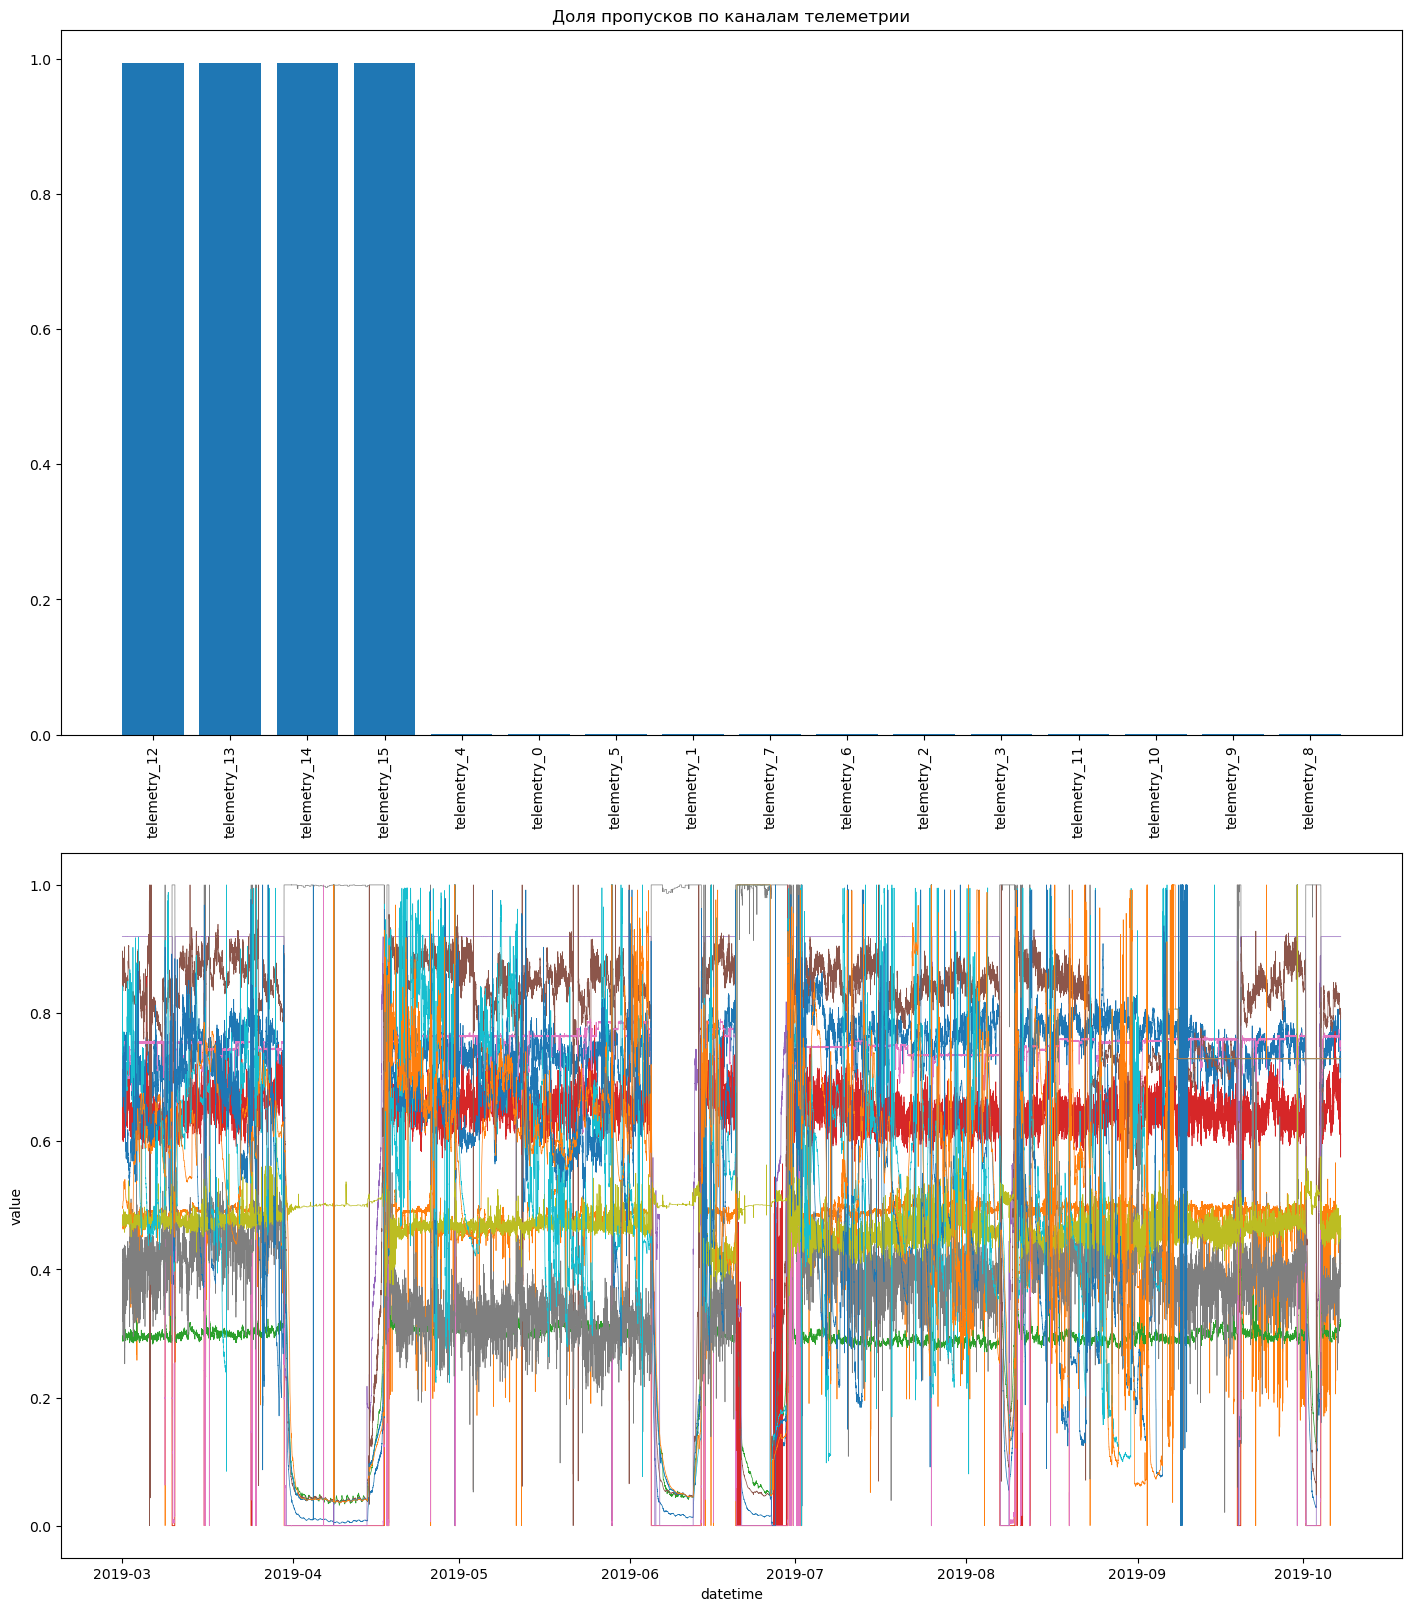

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 16), constrained_layout=True)

missing_share = telemetry[telemetry_cols].isna().mean().sort_values(ascending=False)
axes[0].bar(missing_share.index, missing_share.values)
axes[0].set_title('Доля пропусков по каналам телеметрии')
axes[0].tick_params(axis='x', rotation=90)

for column in usable_telemetry_cols:
    axes[1].plot(telemetry["datetime"], telemetry[column], lw=0.5)
axes[1].set_xlabel('datetime')
axes[1].set_ylabel('value')
plt.show()

Статистики по таргету:


,target_stat
count,1773.000000
mean,0.254272
std,0.092208
min,0.000000
25%,0.175258
50%,0.247423
75%,0.314433
max,0.716495


Интервалы между лабораторными замерами всеми (минуты):


count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: Дата, dtype: float64

Интервалы между лабораторными замерами меньше 10_000 (минуты):


count    1769.000000
mean      139.180328
std       148.207448
min        60.000000
25%       120.000000
50%       120.000000
75%       120.000000
max      4440.000000
Name: Дата, dtype: float64

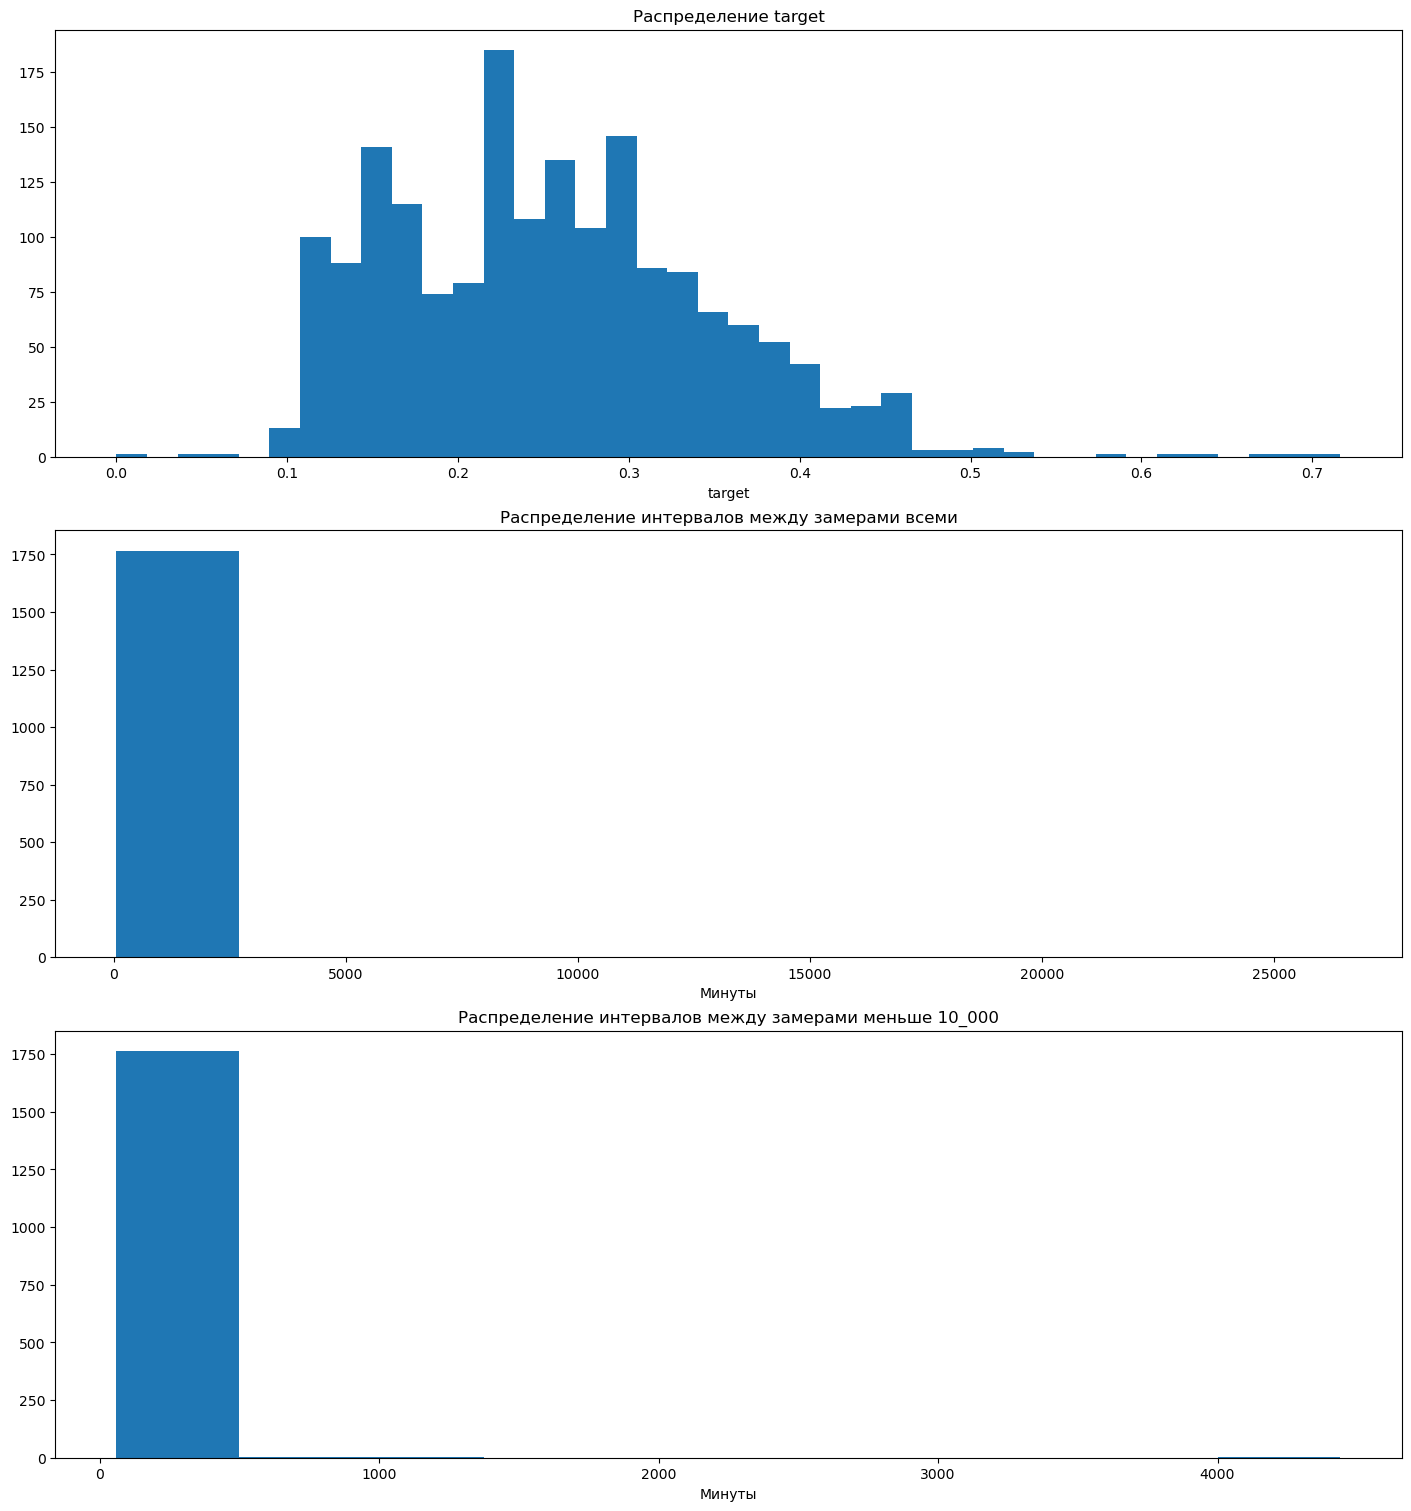

In [33]:
target_intervals = target['Дата'].diff().dt.total_seconds() / 60
target_intervals_small = target_intervals[target_intervals < 10_000]


print('Статистики по таргету:')
target_desc = target['target'].describe().to_frame('target_stat')
display(target_desc)

print('Интервалы между лабораторными замерами всеми (минуты):')
display(target_intervals.describe())
print('Интервалы между лабораторными замерами меньше 10_000 (минуты):')
display(target_intervals_small.describe())

fig, axes = plt.subplots(3, 1, figsize=(14, 15), constrained_layout=True)
axes[0].hist(target['target'], bins=40)
axes[0].set_title('Распределение target')
axes[0].set_xlabel('target')

axes[1].hist(target_intervals.dropna())
axes[1].set_title('Распределение интервалов между замерами всеми')
axes[1].set_xlabel('Минуты')

axes[2].hist(target_intervals_small.dropna())
axes[2].set_title('Распределение интервалов между замерами меньше 10_000')
axes[2].set_xlabel('Минуты')
plt.show()

Отсутствующих минут в телеметрии: 0


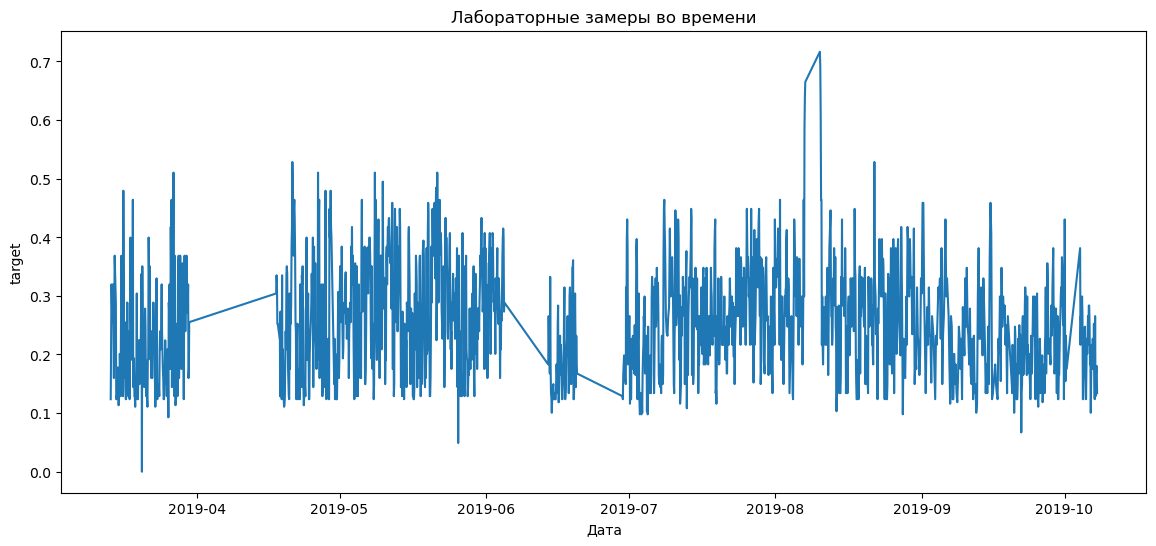

In [35]:
# Проверка полноты минутной сетки и локальных разрывов
minute_grid = pd.date_range(telemetry['datetime'].min(), telemetry['datetime'].max(), freq='min')
missing_timestamps = len(minute_grid.difference(telemetry['datetime']))
print('Отсутствующих минут в телеметрии:', missing_timestamps)

# Визуализация target во времени
plt.figure(figsize=(14, 6))
plt.plot(target['Дата'], target['target'])
plt.title('Лабораторные замеры во времени')
plt.xlabel('Дата')
plt.ylabel('target')
plt.show()

### Синхронизация телеметрии и лабораторных замеров

Лабораторные значения приходят с задержкой 10–15 минут после отбора пробы, поэтому каждому замеру сопоставляем состояние печи на момент Дата - delay.
Оптимальную задержку выбираем из этого диапазона по простому критерию: максимальной средней абсолютной корреляции target с телеметрией после выравнивания.

In [39]:
telemetry_clean = telemetry[['datetime'] + usable_telemetry_cols].copy()
telemetry_clean[usable_telemetry_cols] = telemetry_clean[usable_telemetry_cols].ffill().bfill()

lag_quality = []
for delay in range(10, 16):
    aligned = target.copy()
    aligned['sample_time'] = aligned['Дата'] - pd.Timedelta(minutes=delay)
    merged = pd.merge_asof(
        aligned.sort_values('sample_time'),
        telemetry_clean.sort_values('datetime'),
        left_on='sample_time',
        right_on='datetime',
        direction='backward'
    )
    corr_values = merged[usable_telemetry_cols + ['target']].corr()['target'].drop('target').abs()
    lag_quality.append({
        'delay_min': delay,
        'mean_abs_corr': corr_values.mean(),
        'max_abs_corr': corr_values.max()
    })

lag_quality = pd.DataFrame(lag_quality).sort_values(['mean_abs_corr', 'max_abs_corr'], ascending=False)
display(lag_quality)

BEST_DELAY = int(lag_quality.iloc[0]['delay_min'])
print('Выбранная задержка (мин):', BEST_DELAY)

,delay_min,mean_abs_corr,max_abs_corr
1,11,0.085194,0.180849
2,12,0.085019,0.179327
3,13,0.084618,0.178424
0,10,0.084541,0.182428
4,14,0.083815,0.177402
5,15,0.083776,0.176359


Выбранная задержка (мин): 11


### Обоснование обработки пропусков и аномалий

- Каналы `telemetry_12`–`telemetry_15` почти полностью пустые, поэтому исключаются как потенциальный источник шума.
- Редкие пропуски в остальных каналах заполняются с помощью `forward fill`. Для минутной промышленной телеметрии это допустимо, так как соседние значения обычно физически близки.
- Значения не удаляются автоматически по IQR или z-score: экстремальные значения могут отражать переходные режимы печи. Устойчивость к таким значениям должна обеспечиваться моделью и выбором признаков

### Выводы по пункту 2.1

1. Телеметрия почти полностью покрывает данные с минутной частотой, но каналы `telemetry_12`–`telemetry_15` практически неинформативны.
2. Лабораторные замеры поступают нерегулярно: обычно раз в 2 часа, но встречаются более длинные паузы.
3. Для обучения необходимо учитывать временной сдвиг между телеметрией и target из-за задержки отбора и анализа пробы.
4. Базовая обработка: удалить почти пустые признаки, заполнить короткие пропуски и формировать признаки по историческому окну до момента отбора пробы.

## 2.2. Инжиниринг признаков для временных рядов

* Создать лаговые признаки (lag features) для ключевых показателей телеметрии
* Рассчитать скользящие статистики (mean, std, min, max) с различными окнами
* Добавить признаки, отражающие динамику изменений (производные, темпы роста)
* При необходимости выполнить снижение размерности (PCA) или отбор признаков
* Обосновать выбор признаков с точки зрения интерпретируемости и вклада в прогноз

In [44]:
def build_telemetry_features(
    df,
    cols,
    windows=(5, 15, 30, 60),
    lags=(1, 5, 15, 30, 60),
    diffs=(1, 5, 15),
):
    """Формирует признаки по телеметрии: скользящие статистики, лаги, динамику и календарные признаки."""
    
    feature_blocks = [df[['datetime'] + cols].copy()]

    # Скользящие статистики
    for window in windows:
        rolling = df[cols].rolling(window=window, min_periods=1)

        feature_blocks.extend([
            rolling.mean().add_suffix(f'_roll_mean_{window}'),
            rolling.std().add_suffix(f'_roll_std_{window}'),
            rolling.min().add_suffix(f'_roll_min_{window}'),
            rolling.max().add_suffix(f'_roll_max_{window}'),
        ])

    # Лаговые признаки
    for lag in lags:
        feature_blocks.append(
            df[cols].shift(lag).add_suffix(f'_lag_{lag}')
        )

    # Динамика изменений
    for diff in diffs:
        diff_block = df[cols].diff(diff).add_suffix(f'_diff_{diff}')
        rate_block = (
            df[cols]
            .pct_change(diff)
            .replace([np.inf, -np.inf], np.nan)
            .add_suffix(f'_rate_{diff}')
        )

        feature_blocks.extend([diff_block, rate_block])

    # Объединение всех признаков
    feat = pd.concat(feature_blocks, axis=1)

    # Календарные признаки
    datetime_col = df['datetime']
    feat['hour'] = datetime_col.dt.hour
    feat['dayofweek'] = datetime_col.dt.dayofweek
    feat['dayofmonth'] = datetime_col.dt.day
    feat['month'] = datetime_col.dt.month

    return feat.replace([np.inf, -np.inf], np.nan)


telemetry_features = build_telemetry_features(
    telemetry_clean,
    usable_telemetry_cols
)

print('Сформировано признаков:', telemetry_features.shape[1] - 1)
display(telemetry_features.head())

Сформировано признаков: 340


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_0_roll_mean_5,telemetry_1_roll_mean_5,telemetry_2_roll_mean_5,telemetry_3_roll_mean_5,telemetry_4_roll_mean_5,telemetry_5_roll_mean_5,telemetry_6_roll_mean_5,telemetry_7_roll_mean_5,telemetry_8_roll_mean_5,telemetry_9_roll_mean_5,telemetry_10_roll_mean_5,telemetry_11_roll_mean_5,telemetry_0_roll_std_5,telemetry_1_roll_std_5,telemetry_2_roll_std_5,telemetry_3_roll_std_5,telemetry_4_roll_std_5,telemetry_5_roll_std_5,telemetry_6_roll_std_5,telemetry_7_roll_std_5,telemetry_8_roll_std_5,telemetry_9_roll_std_5,telemetry_10_roll_std_5,telemetry_11_roll_std_5,telemetry_0_roll_min_5,telemetry_1_roll_min_5,telemetry_2_roll_min_5,telemetry_3_roll_min_5,telemetry_4_roll_min_5,telemetry_5_roll_min_5,telemetry_6_roll_min_5,telemetry_7_roll_min_5,telemetry_8_roll_min_5,telemetry_9_roll_min_5,telemetry_10_roll_min_5,telemetry_11_roll_min_5,telemetry_0_roll_max_5,telemetry_1_roll_max_5,telemetry_2_roll_max_5,telemetry_3_roll_max_5,telemetry_4_roll_max_5,telemetry_5_roll_max_5,telemetry_6_roll_max_5,telemetry_7_roll_max_5,telemetry_8_roll_max_5,telemetry_9_roll_max_5,telemetry_10_roll_max_5,telemetry_11_roll_max_5,telemetry_0_roll_mean_15,telemetry_1_roll_mean_15,telemetry_2_roll_mean_15,telemetry_3_roll_mean_15,telemetry_4_roll_mean_15,telemetry_5_roll_mean_15,telemetry_6_roll_mean_15,telemetry_7_roll_mean_15,telemetry_8_roll_mean_15,telemetry_9_roll_mean_15,telemetry_10_roll_mean_15,telemetry_11_roll_mean_15,telemetry_0_roll_std_15,telemetry_1_roll_std_15,telemetry_2_roll_std_15,telemetry_3_roll_std_15,telemetry_4_roll_std_15,telemetry_5_roll_std_15,telemetry_6_roll_std_15,telemetry_7_roll_std_15,telemetry_8_roll_std_15,telemetry_9_roll_std_15,telemetry_10_roll_std_15,telemetry_11_roll_std_15,telemetry_0_roll_min_15,telemetry_1_roll_min_15,telemetry_2_roll_min_15,telemetry_3_roll_min_15,telemetry_4_roll_min_15,telemetry_5_roll_min_15,telemetry_6_roll_min_15,telemetry_7_roll_min_15,telemetry_8_roll_min_15,telemetry_9_roll_min_15,telemetry_10_roll_min_15,telemetry_11_roll_min_15,telemetry_0_roll_max_15,telemetry_1_roll_max_15,telemetry_2_roll_max_15,...,telemetry_0_lag_30,telemetry_1_lag_30,telemetry_2_lag_30,telemetry_3_lag_30,telemetry_4_lag_30,telemetry_5_lag_30,telemetry_6_lag_30,telemetry_7_lag_30,telemetry_8_lag_30,telemetry_9_lag_30,telemetry_10_lag_30,telemetry_11_lag_30,telemetry_0_lag_60,telemetry_1_lag_60,telemetry_2_lag_60,telemetry_3_lag_60,telemetry_4_lag_60,telemetry_5_lag_60,telemetry_6_lag_60,telemetry_7_lag_60,telemetry_8_lag_60,telemetry_9_lag_60,telemetry_10_lag_60,telemetry_11_lag_60,telemetry_0_diff_1,telemetry_1_diff_1,telemetry_2_diff_1,telemetry_3_diff_1,telemetry_4_diff_1,telemetry_5_diff_1,telemetry_6_diff_1,telemetry_7_diff_1,telemetry_8_diff_1,telemetry_9_diff_1,telemetry_10_diff_1,telemetry_11_diff_1,telemetry_0_rate_1,telemetry_1_rate_1,telemetry_2_rate_1,telemetry_3_rate_1,telemetry_4_rate_1,telemetry_5_rate_1,telemetry_6_rate_1,telemetry_7_rate_1,telemetry_8_rate_1,telemetry_9_rate_1,telemetry_10_rate_1,telemetry_11_rate_1,telemetry_0_diff_5,telemetry_1_diff_5,telemetry_2_diff_5,telemetry_3_diff_5,telemetry_4_diff_5,telemetry_5_diff_5,telemetry_6_diff_5,telemetry_7_diff_5,telemetry_8_diff_5,telemetry_9_diff_5,telemetry_10_diff_5,telemetry_11_diff_5,telemetry_0_rate_5,telemetry_1_rate_5,telemetry_2_rate_5,telemetry_3_rate_5,telemetry_4_rate_5,telemetry_5_rate_5,telemetry_6_rate_5,telemetry_7_rate_5,telemetry_8_rate_5,telemetry_9_rate_5,telemetry_10_rate_5,telemetry_11_rate_5,telemetry_0_diff_15,telemetry_1_diff_15,telemetry_2_diff_15,telemetry_3_diff_15,telemetry_4_diff_15,telemetry_5_diff_15,telemetry_6_diff_15,telemetry_7_diff_15,telemetry_8_diff_15,telemetry_9_diff_15,telemetry_10_diff_15,telemetry_11_diff_15,telemetry_0_rate_15,telemetry_1_rate_15,telemetry_2_rate_15,telemetry_3_rate_15,telemetry_4_rate_15,telemetry_5_rate_15,telemetry_6_rate_15,

In [45]:
# Привязка target к состоянию печи на момент отбора пробы
aligned_target = (
    target
    .copy()
    .assign(sample_time=lambda df: df['Дата'] - pd.Timedelta(minutes=BEST_DELAY))
    .sort_values('sample_time')
)

telemetry_features_sorted = telemetry_features.sort_values('datetime')

model_df = pd.merge_asof(
    aligned_target,
    telemetry_features_sorted,
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

# Разделение признаков и служебных колонок
service_cols = ['Дата', 'target', 'sample_time', 'datetime']
feature_cols = [col for col in model_df.columns if col not in service_cols]

model_df = model_df.sort_values('Дата').reset_index(drop=True)

# Hold-out по времени: данные не перемешиваем
train_border = int(len(model_df) * 0.8)

train_df = model_df.iloc[:train_border]
valid_df = model_df.iloc[train_border:]

X_train, y_train = train_df[feature_cols], train_df['target']
X_valid, y_valid = valid_df[feature_cols], valid_df['target']

print('train size:', X_train.shape)
print('valid size:', X_valid.shape)

train size: (1418, 340)
valid size: (355, 340)


### Отбор признаков для статистической модели

Для OLS нужна компактная и менее коллинеарная матрица признаков. Поэтому признаки отбираются по train-части с учётом их связи с target, но с ограничением на разнообразие: для каждой пары «тип признака — канал телеметрии» оставляется только лучший по абсолютной корреляции признак.

Такой подход не даёт набору OLS заполниться однотипными скользящими статистиками вроде `roll_max_5`, `roll_max_15`, `roll_max_30` и делает baseline более интерпретируемым.

In [49]:
import re

def get_feature_type(feature_name):
    """Возвращает тип признака: raw, roll_mean, roll_std, lag, diff и т.д."""
    
    patterns = {
        'roll_mean': r'_roll_mean_\d+$',
        'roll_std': r'_roll_std_\d+$',
        'roll_min': r'_roll_min_\d+$',
        'roll_max': r'_roll_max_\d+$',
        'lag': r'_lag_\d+$',
        'diff': r'_diff_\d+$',
        'rate': r'_rate_\d+$',
        'calendar': r'^(hour|dayofweek|dayofmonth|month)$',
    }
    
    for feature_type, pattern in patterns.items():
        if re.search(pattern, feature_name):
            return feature_type
    
    return 'raw'


def get_telemetry_channel(feature_name):
    """Возвращает исходный канал телеметрии, по которому был построен признак."""
    
    if feature_name in ['hour', 'dayofweek', 'dayofmonth', 'month']:
        return 'calendar'
    
    suffix_patterns = [
        r'_roll_mean_\d+$',
        r'_roll_std_\d+$',
        r'_roll_min_\d+$',
        r'_roll_max_\d+$',
        r'_lag_\d+$',
        r'_diff_\d+$',
        r'_rate_\d+$',
    ]
    
    channel = feature_name
    
    for pattern in suffix_patterns:
        channel = re.sub(pattern, '', channel)
    
    return channel

In [64]:
train_for_corr = pd.concat([train_df[feature_cols], y_train], axis=1)

corr_to_target = (
    train_for_corr
    .corr(numeric_only=True)['target']
    .drop('target')
    .abs()
    .sort_values(ascending=False)
)

corr_df = (
    corr_to_target
    .to_frame('abs_corr_with_target')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

corr_df['feature_type'] = corr_df['feature'].apply(get_feature_type)
corr_df['telemetry_channel'] = corr_df['feature'].apply(get_telemetry_channel)

ols_feature_stats = (
    corr_df
    .drop_duplicates(
        subset=['feature_type', 'telemetry_channel'],
        keep='first'
    )
    .head(25)
    .reset_index(drop=True)
)

ols_features = ols_feature_stats['feature'].tolist()

display(ols_feature_stats)
print('Число признаков для OLS:', len(ols_features))

,feature,abs_corr_with_target,feature_type,telemetry_channel
0,telemetry_0_roll_max_60,0.244945,roll_max,telemetry_0
1,telemetry_0,0.225922,raw,telemetry_0
2,telemetry_0_lag_1,0.224124,lag,telemetry_0
3,telemetry_0_roll_mean_5,0.223145,roll_mean,telemetry_0
4,telemetry_0_roll_min_5,0.222567,roll_min,telemetry_0
5,telemetry_5_roll_mean_60,0.189944,roll_mean,telemetry_5
6,telemetry_3_roll_max_30,0.186315,roll_max,telemetry_3
7,telemetry_5_lag_30,0.185304,lag,telemetry_5
8,telemetry_5,0.177158,raw,telemetry_5
9,telemetry_5_roll_min_5,0.176131,roll_min,telemetry_5


Число признаков для OLS: 25


### Выводы по пункту 2.2

1. Для прогноза важны не только текущие значения датчиков, но и краткосрочная история процесса.
2. Лаги, скользящие статистики и признаки динамики помогают учесть инерционность печи и переходные режимы.
3. Для OLS используется компактный и менее коллинеарный набор: по каждой паре «тип признака — канал телеметрии» оставляется лучший признак по абсолютной корреляции с target.
4. Для ансамблевых моделей можно использовать более широкий набор признаков, так как они лучше работают с избыточностью и нелинейными зависимостями.
5. PCA не используется, чтобы сохранить физическую интерпретируемость факторов.

## 2.3. Построение прогнозных моделей

В качестве прогнозных моделей рассматриваем три подхода:

1. **OLS** — интерпретируемый статистический baseline на компактном наборе признаков.
2. **Ridge** — регуляризованная линейная модель, более устойчивая к большому числу коррелированных признаков.
3. **ExtraTreesRegressor** — нелинейный ансамбль деревьев, способный учитывать сложные зависимости между телеметрией и target.

### Почему не используем другие модели

- **ARIMA/Prophet без exogenous-признаков** плохо подходят, так как почти не используют богатую телеметрию и рассматривают target как самостоятельный временной ряд.
- **LSTM/GRU** нецелесообразны: лабораторных замеров немного, они нерегулярны, а данных для обучения глубокой sequence-модели недостаточно.
- **kNN-регрессия** плохо подходит для такой задачи из-за чувствительности к масштабу, высокой размерности и слабой устойчивости к новым режимам процесса.

In [65]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > 1e-8
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def direction_accuracy(y_true, y_pred):
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return (true_diff == pred_diff).mean() * 100


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE_%': mape(y_true, y_pred),
        'WAPE_%': wape(y_true, y_pred),
        'Direction_Acc_%': direction_accuracy(np.asarray(y_true), np.asarray(y_pred))
    }

In [70]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.preprocessing import RobustScaler

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

tscv = TimeSeriesSplit(n_splits=5)


# 1) OLS
ols_imputer = SimpleImputer(strategy='median')

X_train_ols = pd.DataFrame(
    ols_imputer.fit_transform(X_train[ols_features]),
    columns=ols_features,
    index=X_train.index
)

X_valid_ols = pd.DataFrame(
    ols_imputer.transform(X_valid[ols_features]),
    columns=ols_features,
    index=X_valid.index
)

X_train_ols_sm = sm.add_constant(X_train_ols, has_constant='add')
X_valid_ols_sm = sm.add_constant(X_valid_ols, has_constant='add')

start = time.perf_counter()
ols_model = sm.OLS(y_train, X_train_ols_sm).fit()
ols_fit_time = time.perf_counter() - start

ols_pred = ols_model.predict(X_valid_ols_sm)


# 2) Ridge
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('model', Ridge())
])

ridge_grid = {
    'model__alpha': [0.1, 1, 5, 10, 25, 50, 100, 250, 500]
}

ridge_search = GridSearchCV(
    ridge_pipe,
    ridge_grid,
    scoring=mae_scorer,
    cv=tscv,
    n_jobs=-1
)

start = time.perf_counter()
ridge_search.fit(X_train, y_train)
ridge_fit_time = time.perf_counter() - start

ridge_model = ridge_search.best_estimator_
ridge_pred = ridge_model.predict(X_valid)

print('Best Ridge alpha:', ridge_search.best_params_)


# 3) ExtraTrees
et_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

et_grid = {
    'model__n_estimators': [300],
    'model__max_depth': [6, 8, 10, 12],
    'model__min_samples_leaf': [3, 5, 10],
    'model__max_features': ['sqrt', 0.5, 0.8]
}

et_search = GridSearchCV(
    et_pipe,
    et_grid,
    scoring=mae_scorer,
    cv=tscv,
    n_jobs=-1
)

start = time.perf_counter()
et_search.fit(X_train, y_train)
et_fit_time = time.perf_counter() - start

et_model = et_search.best_estimator_
et_pred = et_model.predict(X_valid)

print('Best ExtraTrees params:', et_search.best_params_)

Best Ridge alpha: {'model__alpha': 500}
Best ExtraTrees params: {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


In [71]:
metrics_table = pd.DataFrame([
    {
        'model': 'OLS',
        **regression_metrics(y_valid, ols_pred),
        'fit_time_sec': ols_fit_time,
        'AIC': ols_model.aic,
        'BIC': ols_model.bic
    },
    {
        'model': 'Ridge',
        **regression_metrics(y_valid, ridge_pred),
        'fit_time_sec': ridge_fit_time,
        'AIC': np.nan,
        'BIC': np.nan
    },
    {
        'model': 'ExtraTrees',
        **regression_metrics(y_valid, et_pred),
        'fit_time_sec': et_fit_time,
        'AIC': np.nan,
        'BIC': np.nan
    },
]).sort_values('MAE')

display(metrics_table)

,model,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%,fit_time_sec,AIC,BIC
2,ExtraTrees,0.074114,0.090460,42.622635,32.808936,55.367232,41.857159,NaN,NaN
1,Ridge,0.102397,0.136801,58.205017,45.329276,46.892655,5.163690,NaN,NaN
0,OLS,0.125339,0.145503,72.367611,55.485333,45.197740,0.001723,-2932.868679,-2796.186609


## 2.3. Оценка качества моделей

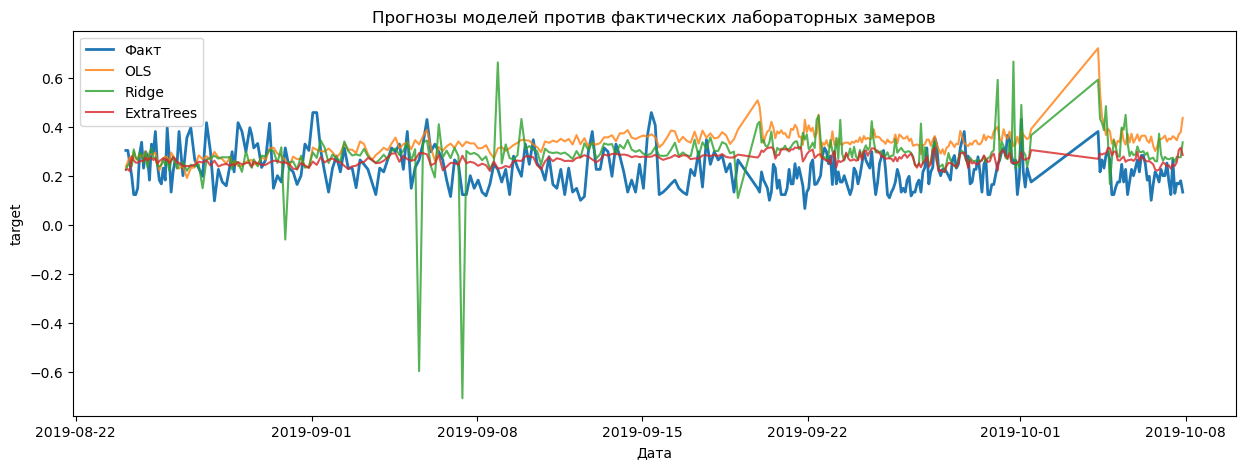

In [72]:
pred_frame = valid_df[['Дата', 'target']].copy()
pred_frame['OLS'] = ols_pred
pred_frame['Ridge'] = ridge_pred
pred_frame['ExtraTrees'] = et_pred

plt.figure(figsize=(15, 5))
plt.plot(pred_frame['Дата'], pred_frame['target'], label='Факт', linewidth=2)
plt.plot(pred_frame['Дата'], pred_frame['OLS'], label='OLS', alpha=0.8)
plt.plot(pred_frame['Дата'], pred_frame['Ridge'], label='Ridge', alpha=0.8)
plt.plot(pred_frame['Дата'], pred_frame['ExtraTrees'], label='ExtraTrees', alpha=0.8)
plt.title('Прогнозы моделей против фактических лабораторных замеров')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.show()

In [76]:
best_model_name = metrics_table.iloc[0]['model']
print('Лучшая модель по MAE:', best_model_name)

if best_model_name == 'ExtraTrees':
    best_pred = et_pred
    best_pipeline = et_model
elif best_model_name == 'Ridge':
    best_pred = ridge_pred
    best_pipeline = ridge_model
else:
    best_pred = ols_pred
    best_pipeline = None

Лучшая модель по MAE: ExtraTrees


,metric,value
0,mean_residual,-0.042081
1,median_residual,-0.042471
2,std_residual,0.080189
3,mean_abs_residual,0.074114
4,max_abs_residual,0.214562


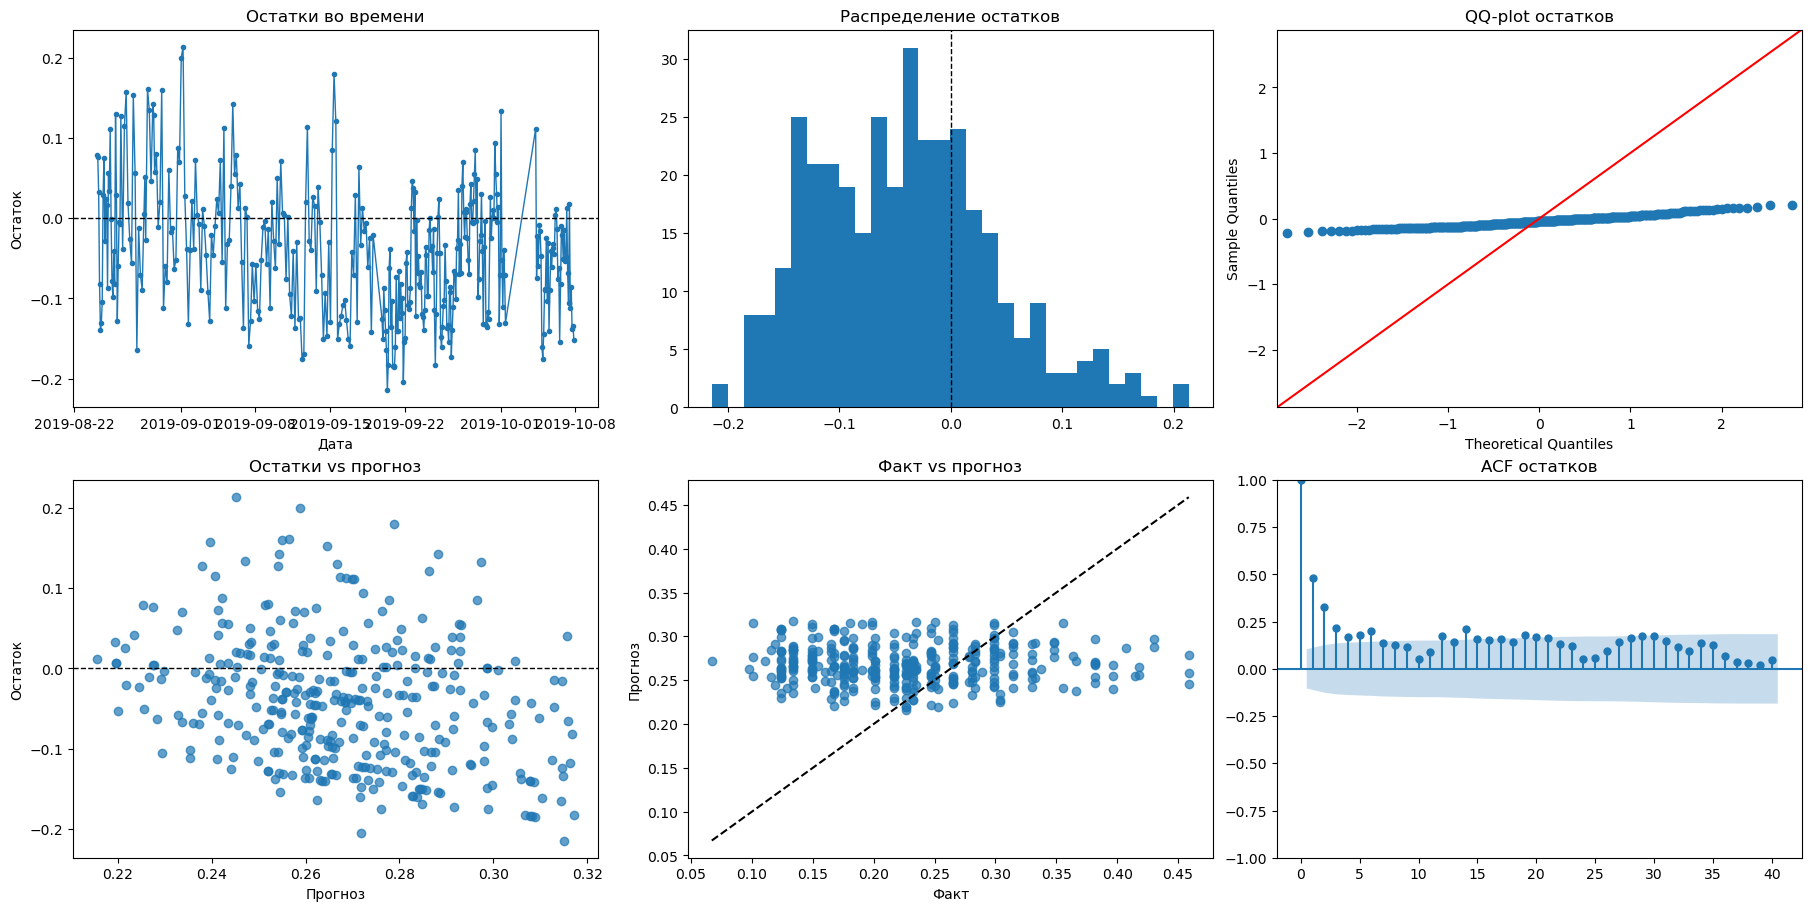

In [77]:
# Остатки лучшей модели
residual_df = pd.DataFrame({
    'Дата': valid_df['Дата'].values,
    'y_true': y_valid.values,
    'y_pred': np.asarray(best_pred)
})

residual_df['residual'] = residual_df['y_true'] - residual_df['y_pred']
residual_df['abs_residual'] = residual_df['residual'].abs()

residuals = residual_df['residual'].values


# Базовая диагностика остатков
residual_summary = pd.DataFrame({
    'metric': [
        'mean_residual',
        'median_residual',
        'std_residual',
        'mean_abs_residual',
        'max_abs_residual'
    ],
    'value': [
        residual_df['residual'].mean(),
        residual_df['residual'].median(),
        residual_df['residual'].std(),
        residual_df['abs_residual'].mean(),
        residual_df['abs_residual'].max()
    ]
})

display(residual_summary)


# Визуальная диагностика
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

# Остатки во времени
axes[0, 0].plot(residual_df['Дата'], residual_df['residual'], marker='o', markersize=3, linewidth=1)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Остаток')

# Распределение остатков
axes[0, 1].hist(residuals, bins=30)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('Распределение остатков')

# QQ-plot
sm.qqplot(residuals, line='45', ax=axes[0, 2])
axes[0, 2].set_title('QQ-plot остатков')

# Остатки vs прогноз
axes[1, 0].scatter(residual_df['y_pred'], residual_df['residual'], alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Остатки vs прогноз')
axes[1, 0].set_xlabel('Прогноз')
axes[1, 0].set_ylabel('Остаток')

# Факт vs прогноз
axes[1, 1].scatter(residual_df['y_true'], residual_df['y_pred'], alpha=0.7)
min_value = min(residual_df['y_true'].min(), residual_df['y_pred'].min())
max_value = max(residual_df['y_true'].max(), residual_df['y_pred'].max())
axes[1, 1].plot([min_value, max_value], [min_value, max_value], linestyle='--', color='black')
axes[1, 1].set_title('Факт vs прогноз')
axes[1, 1].set_xlabel('Факт')
axes[1, 1].set_ylabel('Прогноз')

# ACF остатков
plot_acf(
    residuals,
    ax=axes[1, 2],
    lags=min(40, len(residuals) // 3)
)
axes[1, 2].set_title('ACF остатков')

plt.show()

In [78]:
# Формальные тесты остатков
shapiro_sample = residuals if len(residuals) <= 5000 else np.random.default_rng(RANDOM_STATE).choice(residuals, size=5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

# BP-тест делаем на OLS и, для сравнения, на лучшей модели через вспомогательную регрессию по top-фичам
bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, X_train_ols_sm)

print('Shapiro-Wilk p-value:', shapiro_p)
print('Ljung-Box (lag=10) p-value:', ljung_box['lb_pvalue'].iloc[0])
print('Breusch-Pagan p-value (OLS train residuals):', bp_pvalue)
print('Durbin-Watson (OLS train residuals):', sm.stats.stattools.durbin_watson(ols_model.resid))

Shapiro-Wilk p-value: 0.00010496360784236709
Ljung-Box (lag=10) p-value: 2.9109329134376176e-36
Breusch-Pagan p-value (OLS train residuals): 2.920696396839069e-21
Durbin-Watson (OLS train residuals): 1.0991138543765129


,feature,importance_mean,importance_std
9,telemetry_9,0.004756,0.001536
261,telemetry_9_lag_60,0.003975,0.001284
189,telemetry_9_roll_min_60,0.003935,0.001315
213,telemetry_9_lag_1,0.003694,0.001490
141,telemetry_9_roll_min_30,0.003626,0.001327
76,telemetry_4_roll_std_15,0.003288,0.000468
225,telemetry_9_lag_5,0.003247,0.001220
45,telemetry_9_roll_min_5,0.003239,0.000895
117,telemetry_9_roll_mean_30,0.003027,0.001519
105,telemetry_9_roll_max_15,0.002919,0.000822


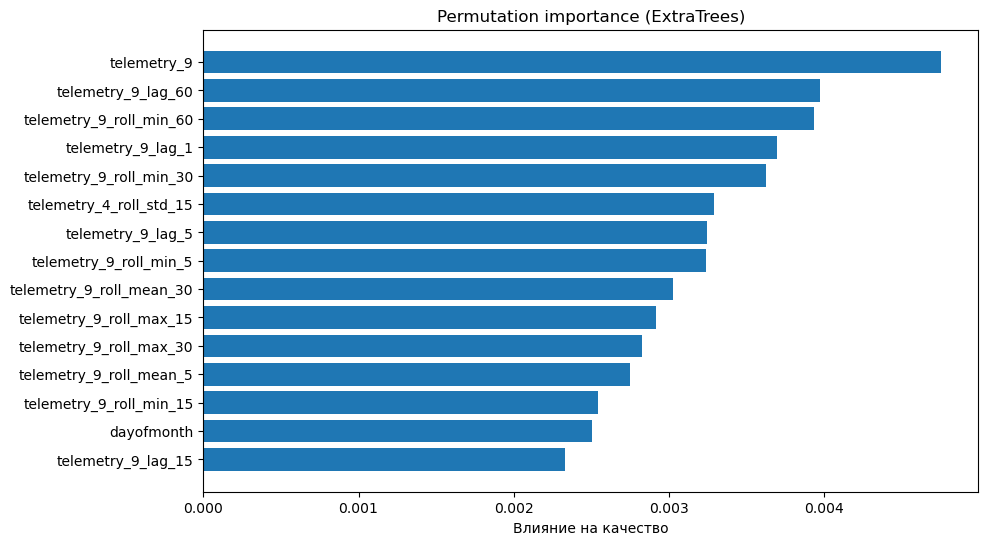

In [79]:
# permutation importance для лучшей ML-модели
if best_model_name in ['Ridge', 'ExtraTrees']:
    result = permutation_importance(
        best_pipeline,
        X_valid,
        y_valid,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    importance_df = pd.DataFrame({
        'feature': X_valid.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values('importance_mean', ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    top_imp = importance_df.head(15).sort_values('importance_mean')
    plt.barh(top_imp['feature'], top_imp['importance_mean'])
    plt.title(f'Permutation importance ({best_model_name})')
    plt.xlabel('Влияние на качество')
    plt.show()
else:
    importance_df = pd.DataFrame({'feature': ols_model.params.index[1:], 'importance_mean': np.abs(ols_model.params.values[1:])})
    importance_df = importance_df.sort_values('importance_mean', ascending=False)
    display(importance_df.head(20))

In [82]:
import shap

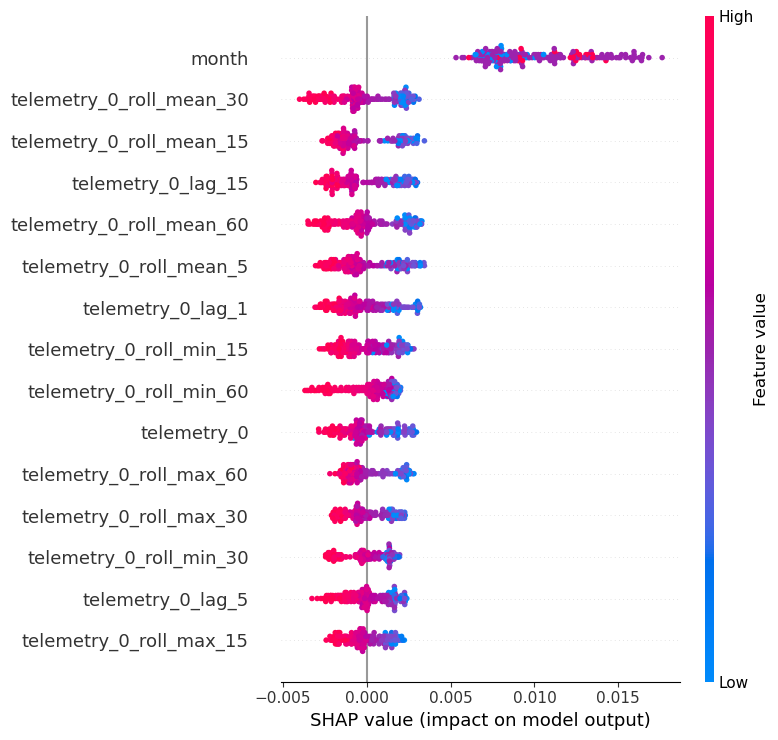

In [83]:
et_imputer = et_model.named_steps['imputer']
et_estimator = et_model.named_steps['model']
X_valid_imp = pd.DataFrame(et_imputer.transform(X_valid), columns=X_valid.columns, index=X_valid.index)
shap_sample = X_valid_imp.sample(min(200, len(X_valid_imp)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(et_estimator)
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, max_display=15)

### Интерпретация физики процесса

Важности признаков можно интерпретировать с точки зрения работы печи:

- **Текущие значения телеметрии** показывают прямую связь target с текущим режимом процесса.
- **Лаги и скользящие средние** указывают на инерционность печи: результат зависит не только от текущего состояния, но и от накопленной истории.
- **Скользящее стандартное отклонение и diff-признаки** отражают влияние переходных режимов и нестабильности процесса на качество.

### Выводы по пункту 2.3

1. Качество моделей оценивается не только по абсолютной ошибке, но и по способности корректно отслеживать направление изменения target.
2. **OLS** используется как интерпретируемый baseline: он даёт понятную связь признаков с target и позволяет рассчитать AIC/BIC.
3. **Ridge** повышает устойчивость линейной модели при большом числе коррелированных лаговых и скользящих признаков.
4. **ExtraTreesRegressor** учитывает нелинейные зависимости между режимами печи и лабораторной концентрацией, но его выводы нужно дополнительно проверять по остаткам и временной стабильности прогноза.

## 2.4. Документирование и интерпретация

Ниже — автоматическая текстовая сводка с основными результатами ноутбука.

In [84]:
best_row = metrics_table.sort_values('MAE').iloc[0]
summary = {
    'best_delay_min': BEST_DELAY,
    'best_model': best_row['model'],
    'best_metrics': {
        'MAE': float(best_row['MAE']),
        'RMSE': float(best_row['RMSE']),
        'MAPE_%': float(best_row['MAPE_%']),
        'WAPE_%': float(best_row['WAPE_%']),
        'Direction_Acc_%': float(best_row['Direction_Acc_%'])
    },
    'sparse_features_removed': very_sparse_cols,
    'n_train_rows': int(len(train_df)),
    'n_valid_rows': int(len(valid_df))
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "best_delay_min": 11,
  "best_model": "ExtraTrees",
  "best_metrics": {
    "MAE": 0.07411427644035548,
    "RMSE": 0.0904603110777252,
    "MAPE_%": 42.6226351457588,
    "WAPE_%": 32.808936001589466,
    "Direction_Acc_%": 55.367231638418076
  },
  "sparse_features_removed": [
    "telemetry_12",
    "telemetry_13",
    "telemetry_14",
    "telemetry_15"
  ],
  "n_train_rows": 1418,
  "n_valid_rows": 355
}


### Итоговые аналитические выводы по пункту 2.4

1. Виртуальный датчик можно строить как supervised-модель на синхронизированных данных телеметрии и лабораторных замеров.
2. Ключевой момент качества — корректное временное выравнивание с учётом задержки отбора/анализа пробы.
3. Наиболее полезные признаки отражают не только уровень сигналов, но и их историю: лаги, скользящие окна и изменения.
4. Для промышленного внедрения рекомендуется регулярно переобучать модель, отслеживать сдвиг распределений и использовать лучший алгоритм как soft-sensor рядом с лабораторными измерениями.

## Тестирование

Берём лучшую модель, выбранную по validation-части, и переобучаем её на всех доступных обучающих данных. Затем строим признаки для `data_test_small.csv`, синхронизируем их с лабораторными замерами из `target_test_small.csv` с учётом найденной задержки и оцениваем качество на test-наборе.

Test-набор не используется для подбора модели или параметров, а нужен только для финальной проверки качества.

In [87]:
from sklearn.base import clone

# Загрузка test-данных
telemetry_test = (
    pd.read_csv('data_test_small.csv', parse_dates=['datetime'])
    .sort_values('datetime')
    .reset_index(drop=True)
)

target_test = (
    pd.read_csv('target_test_small.csv', parse_dates=['Дата'])
    .sort_values('Дата')
    .reset_index(drop=True)
)


# Подготовка test-телеметрии
telemetry_test = telemetry_test[['datetime'] + usable_telemetry_cols].copy()
telemetry_test[usable_telemetry_cols] = telemetry_test[usable_telemetry_cols].ffill().bfill()

telemetry_test_features = build_telemetry_features(
    telemetry_test,
    usable_telemetry_cols
)


# Привязка test-target к состоянию печи на момент отбора пробы
target_test_aligned = (
    target_test
    .copy()
    .assign(sample_time=lambda df: df['Дата'] - pd.Timedelta(minutes=BEST_DELAY))
    .sort_values('sample_time')
)

test_model_df = pd.merge_asof(
    target_test_aligned,
    telemetry_test_features.sort_values('datetime'),
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

test_model_df = (
    test_model_df
    .sort_values('Дата')
    .reset_index(drop=True)
)


# Проверка результата выравнивания
print('Размер test после выравнивания:', test_model_df.shape)
print('Пропусков в target:', test_model_df['target'].isna().sum())
print('Пропусков в datetime после merge_asof:', test_model_df['datetime'].isna().sum())


# Финальное обучение на всех доступных train-данных
full_X = model_df[feature_cols]
full_y = model_df['target']

X_test = test_model_df[feature_cols]
y_test = test_model_df['target']


if best_model_name in ['ExtraTrees', 'Ridge']:
    base_model = et_model if best_model_name == 'ExtraTrees' else ridge_model

    final_model = clone(base_model)
    final_model.fit(full_X, full_y)

    test_pred = final_model.predict(X_test)

else:
    ols_imputer_final = SimpleImputer(strategy='median')

    full_X_ols = pd.DataFrame(
        ols_imputer_final.fit_transform(model_df[ols_features]),
        columns=ols_features,
        index=model_df.index
    )

    test_X_ols = pd.DataFrame(
        ols_imputer_final.transform(test_model_df[ols_features]),
        columns=ols_features,
        index=test_model_df.index
    )

    final_ols = sm.OLS(
        full_y,
        sm.add_constant(full_X_ols, has_constant='add')
    ).fit()

    test_pred = final_ols.predict(
        sm.add_constant(test_X_ols, has_constant='add')
    )


# Метрики на test_small
test_metrics = pd.DataFrame([
    {
        'model': best_model_name,
        **regression_metrics(y_test, test_pred)
    }
])

print('Метрики на test_small:')
display(test_metrics)

Размер test после выравнивания: (318, 344)
Пропусков в target: 0
Пропусков в datetime после merge_asof: 0
Метрики на test_small:


,model,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%
0,ExtraTrees,0.061707,0.076525,34.066076,29.425693,54.574132
